In [2]:
%pip install pandas
import pandas as pd
%pip install matplotlib
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.3.2 -> 26.1.2
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.3.2 -> 26.1.2
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


INTRODUCCION
-Paso uno Entender la estructura y la unidad de analisis:
*Al amalisar el datase podemos entender que se basa en post/publicaciones y no tanto en el ususario ya que cada fila es un post/publicaion distinta que pueden ser del mismo ususrario u otro con cualidades de difieren como la fecha, dispositivo deonde publico etc.



Paso Dos  Detectar y medir inconsistencias:
Realizamos el primer paso que es la deteccion de inconsistencias para poder tener una vision completa del dataset, y para tener en cuenta que debemos limpiar a futuro

In [3]:
#leemos el csv y lo trasnformamos en u dataframe
df = pd.read_csv("product_activity (1).csv")

# Exploración inicial
df.head()


,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
0,U01988,2025-02-18T02:07:44,PY,pro,26.0,P0008515,sport,2025-05-07T20:55:28,7,16,78,mobile
1,U00236,2025-06-22T07:49:10,BR,free,27.0,P0001023,tech,2025-09-13T20:31:06,1,9,83,web
2,U00791,2024-02-12T02:45:45,CL,free,28.0,P0003405,tech,2024-02-14T05:17:48,11,2,2,mobile
3,U01522,2024-09-22T07:06:50,US,free,16.0,P0006524,finance,2024-09-24T07:51:34,5,2,2,web
4,U01092,2025-07-18T02:27:52,PY,free,NaN,P0004665,education,2025-07-24T04:56:56,7,2,6,mobile


podemos observar un breve resumen del data set

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8782 entries, 0 to 8781
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            8782 non-null   str    
 1   created_at         8782 non-null   str    
 2   country            8782 non-null   str    
 3   plan_type          8782 non-null   str    
 4   user_age           8028 non-null   float64
 5   post_id            8782 non-null   str    
 6   post_category      8782 non-null   str    
 7   post_created_at    8782 non-null   str    
 8   votes_received     8782 non-null   int64  
 9   user_total_posts   8782 non-null   int64  
 10  days_since_signup  8782 non-null   int64  
 11  device_type        8782 non-null   str    
dtypes: float64(1), int64(3), str(8)
memory usage: 823.4 KB


-Ante este resumen podemos ver que nusetros usuarios son personas entre 22 a 33 años de edad con un promedio de 27 de edad general, nuetros usuarios principalmente son gente joven
-que los votos esta centralizados a pocos usuarios podemos observar en el promedio de la mayoria no supera los 10 votos pero encambio el maximo es de 74  votos denotando una diferencia clara.
-se puede decir lo mismo de la cantidad de post publicados pero sin tanta brecha entre usuarios
-con las fechas podemos decir que la mayoria de los usuarios llevan mas de un mes registrados y que hay tambien la diferencia entre el mas viejo y el promedio de 75%

In [64]:
df.describe()

,user_age,votes_received,user_total_posts,days_since_signup
count,8028.000000,8782.000000,8782.000000,8782.000000
mean,27.902591,6.918356,8.324186,29.479390
std,7.547052,5.127311,6.754906,36.819928
min,16.000000,0.000000,1.000000,0.000000
25%,22.000000,3.000000,4.000000,5.000000
50%,28.000000,6.000000,6.000000,17.000000
75%,33.000000,9.000000,11.000000,40.000000
max,58.000000,74.000000,39.000000,404.000000


In [4]:
#cantidad de filas y columnas
print(f"filas: {df.shape[0]}, columnas: {df.shape[1]}")

#filas duplicadas
print(f"\nfilas duplicadas: {df.duplicated().sum()}")

filas: 8782, columnas: 12

filas duplicadas: 172


Este dtaframe nos demuetra dos cosas
1-que los textos falta normalisarlos
2-hay una buena cantidad de valores nulos

In [42]:
#valores nulos o faltantes de tipo de plan
print(df["plan_type"].value_counts(dropna=False))

plan_type
free            5978
pro             1460
enterprise       306
Free             208
 free            197
FREE             196
FreE             189
PRo               46
 pro              44
PRO               44
Pro               38
Pro               35
EnterPrise        13
ENTERPRISE        11
 enterprise        7
Enterprise         7
premium            1
vip                1
enterprise+        1
Name: count, dtype: int64


In [53]:
#valores nulos o faltantes de categoria de publicacion
print(df["post_category"].value_counts(dropna=False))

post_category
tech           1187
life            913
sports          899
science         753
finance         739
gaming          727
music           614
health          601
education       592
travel          445
 tech            70
Tech             67
TECH             56
tehc             50
Life             46
Finance          44
 sport           42
sciense          42
gamming          40
 life            38
SPORTS           37
 finance         37
LIFE             36
Sports           36
 science         35
sporst           35
Gaming           35
Science          34
 gaming          33
SCIENCE          33
finanse          32
FINANCE          31
EDUCATION        31
educatoin        31
Music            28
healt            28
 health          26
Education        25
GAMING           22
 education       21
Health           21
MUSIC            21
lfe              21
 music           20
Travel           20
TRAVEL           19
HEALTH           18
 travel          16
trvael           16
musc  

In [44]:
#valores nulos o faltantes de dispositivo usado
print(df["device_type"].value_counts(dropna=False))

device_type
web        4416
mobile     3761
desktop     602
tablet        1
console       1
phone         1
Name: count, dtype: int64


-Paso tres limpiar con criterio:
Paso crucial para poder trabajar de manera optima con el datset, en donde normalizamos la mayoria de los textos, este paso es necesario porque nos entrga el dataset filtrado y pulcro para poder ser estudiado

In [5]:
#copiamos el dataset para mantener intacto el original y poder trebajar con la copia
df_limpio= df.copy()

#borramos las 172 filas duplicadas
df_limpio= df_limpio.drop_duplicates()

#limpiamos los textos strip() para eliminar espacios y lower() para convertir en minusculas
df_limpio["plan_type"]=df_limpio["plan_type"].str.strip().str.lower()
df_limpio["post_category"] = df_limpio["post_category"].str.strip().str.lower()
df_limpio["device_type"] = df_limpio["device_type"].str.strip().str.lower()

#creamos un diccionario para normalizar los textos en categoria de publicacion
category_corrections = {
    "tehc": "tech",
    "finanse": "finance",
    "sciense": "science",
    "gamming": "gaming",
    "sporst": "sports",
    "educatoin": "education",
    "healt": "health",
    "lfe": "life",
    "trvael": "travel",
    "musc": "music",
    "sport": "sports",
    "sp0rts": "sports"
}
#reemplazamos los valores mal escritos
df_limpio["post_category"]=df_limpio["post_category"].replace(category_corrections)

#convertimos las fechas en datetime, errors="coerce" convierte las fechas invalidas en nulas
df_limpio["created_at"]=pd.to_datetime(df_limpio["created_at"], errors="coerce")

df_limpio["post_created_at"] = pd.to_datetime(df_limpio["post_created_at"], errors="coerce")


#seleccionamos todas las filas que no contengan los valores validos para cada columna
planes_validos=["free", "pro", "enterprise"]

df_limpio.loc[~df_limpio["plan_type"].isin(planes_validos),"plan_type"]= "invalido"

dispositivos_validos=["web","mobile","desktop"]

df_limpio.loc[~df_limpio["device_type"].isin(dispositivos_validos),"device_type"]= "invalido"

categorias_validas= [
    "tech", "life", "sports", "science", "finance",
    "gaming", "music", "education", "health", "travel"
]

df_limpio.loc[~df_limpio["post_category"].isin(categorias_validas),"post_category"]= "invalido"

#revisamos las fechas incongruentes de creacion
df_limpio["post_before_signup"] = df_limpio["post_created_at"] < df_limpio["created_at"]

#recalculamos las fechas
df_limpio["days_since_signup_clean"] = (
    df_limpio["post_created_at"] - df_limpio["created_at"]
).dt.days

#Resumen final de la limpieza
print("Filas originales:", df.shape[0])
print("Filas después de limpieza:", df_limpio.shape[0])
print("Duplicados restantes:", df_limpio.duplicated().sum())

print("\nValores faltantes después de limpieza:")
print(df_limpio.isna().sum())

print("\nDistribución final de plan_type:")
print(df_limpio["plan_type"].value_counts(dropna=False))

print("\nDistribución final de post_category:")
print(df_limpio["post_category"].value_counts(dropna=False))

print("\nDistribución final de device_type:")
print(df_limpio["device_type"].value_counts(dropna=False))

print("\nPosts creados antes del registro:")
print(df_limpio["post_before_signup"].value_counts())


Filas originales: 8782
Filas después de limpieza: 8610
Duplicados restantes: 0

Valores faltantes después de limpieza:
user_id                      0
created_at                   1
country                      0
plan_type                    0
user_age                   738
post_id                      0
post_category                0
post_created_at              1
votes_received               0
user_total_posts             0
days_since_signup            0
device_type                  0
post_before_signup           0
days_since_signup_clean      2
dtype: int64

Distribución final de plan_type:
plan_type
free          6637
pro           1631
enterprise     339
invalido         3
Name: count, dtype: int64

Distribución final de post_category:
post_category
tech         1397
life         1039
sports       1028
science       882
finance       865
gaming        844
education     687
music         685
health        681
travel        500
invalido        2
Name: count, dtype: int64

Distribució

LIMPIEZA
En base a la limpieza final podemos observar que ya casi no hay valores nulos en la mayoria de columnas, sin incluir a user_age que tiene muchos valores nulos

In [68]:

# Comparar days_since_signup original con el calculado
df_limpio["days_inconsistent"] = (
    df_limpio["days_since_signup"] != df_limpio["days_since_signup_clean"]
)

print("Days_since_signup inconsistentes:")
print(df_limpio["days_inconsistent"].value_counts())


Days_since_signup inconsistentes:
days_inconsistent
True     4401
False    4209
Name: count, dtype: int64


Se da a entender por este grafico que hay una cantidad muy grande en fchas que son logicas debido a que la creacion de ususrio puede ser mayor a la fecha de publicacion de un post

Etapa de cuarentena, dividimos el dataset en partes para solo poder analizar los datos no problematicos, esto nos sirve para tener una trazabilidad del problema y tambien para no eliminar los erros de manera inmediata 

In [8]:
df_limpio["reason_code"] = ""

df_limpio.loc[
    df_limpio["created_at"].isna(),
    "reason_code"
] += "invalid_signup_date;"

df_limpio.loc[
    df_limpio["post_created_at"].isna(),
    "reason_code"
] += "invalid_post_date;"

df_limpio.loc[
    df_limpio["post_created_at"] < df_limpio["created_at"],
    "reason_code"
] += "post_before_signup;"

df_limpio.loc[
    df_limpio["plan_type"] == "unknown",
    "reason_code"
] += "invalid_plan_type;"

df_limpio.loc[
    df_limpio["device_type"] == "unknown",
    "reason_code"
] += "invalid_device_type;"

df_limpio.loc[
    df_limpio["post_category"] == "unknown",
    "reason_code"
] += "invalid_post_category;"

df_quarantine = df_limpio[df_limpio["reason_code"] != ""].copy()
df_analysis = df_limpio[df_limpio["reason_code"] == ""].copy()

print("Filas en cuarentena:", df_quarantine.shape[0])
print("Filas para análisis:", df_analysis.shape[0])

Filas en cuarentena: 97
Filas para análisis: 8513


en este caso observamos 97 filas que crean conflicto que fueron aisladas

In [69]:
# ===============================
# Data Quality Report
# ===============================

# Cantidad de filas del dataset original
raw_rows = df.shape[0]

# Cantidad de filas del dataset limpio/core
core_rows = df_analysis.shape[0]

# Cantidad de filas enviadas a cuarentena
quarantine_rows = df_quarantine.shape[0]

# Porcentaje de filas en cuarentena sobre el dataset limpio previo a separar
quarantine_pct = (quarantine_rows / df_limpio.shape[0]) * 100

# Cantidad de duplicados removidos
duplicates_removed = df.duplicated().sum()

# Porcentaje de inconsistencias entre days_since_signup original y calculado
date_mismatch_pct = df_limpio["days_inconsistent"].mean() * 100

# Creamos tabla resumen del reporte
quality_report = pd.DataFrame({
    "metric": [
        "RAW rows",
        "CORE rows",
        "Quarantine rows",
        "Quarantine %",
        "Duplicates removed",
        "Date mismatch %"
    ],
    "value": [
        raw_rows,
        core_rows,
        quarantine_rows,
        round(quarantine_pct, 2),
        duplicates_removed,
        round(date_mismatch_pct, 2)
    ]
})

quality_report

,metric,value
0,RAW rows,8782.00
1,CORE rows,8513.00
2,Quarantine rows,97.00
3,Quarantine %,1.13
4,Duplicates removed,172.00
5,Date mismatch %,51.11


In [9]:
# ===============================
# 4. Métricas y Análisis
# ===============================

# Usamos el dataset limpio/core
data = df_analysis.copy()

# Usuarios únicos por plan
usuarios_por_plan = data.groupby("plan_type")["user_id"].nunique()

print("Usuarios únicos por plan:")
print(usuarios_por_plan)

Usuarios únicos por plan:
plan_type
enterprise      82
free          1547
invalido         3
pro            368
Name: user_id, dtype: int64


In [71]:
# Cantidad de posts por país
posts_por_pais = data.groupby("country")["post_id"].count().sort_values(ascending=False)

print("Posts por país:")
print(posts_por_pais)

Posts por país:
country
US    1874
BR    1601
AR    1169
PY     837
MX     802
CL     553
ES     547
CO     489
PE     393
UY     248
Name: post_id, dtype: int64


In [72]:
# Cantidad de posts por categoría
posts_por_categoria = data.groupby("post_category")["post_id"].count().sort_values(ascending=False)

print("Posts por categoría:")
print(posts_por_categoria)

Posts por categoría:
post_category
tech         1382
life         1034
sports       1017
science       870
finance       854
gaming        833
education     682
health        674
music         673
travel        492
invalido        2
Name: post_id, dtype: int64


In [73]:
# Cantidad de posts por dispositivo
posts_por_dispositivo = data.groupby("device_type")["post_id"].count().sort_values(ascending=False)

print("Posts por dispositivo:")
print(posts_por_dispositivo)

Posts por dispositivo:
device_type
web         4270
mobile      3657
desktop      583
invalido       3
Name: post_id, dtype: int64


In [74]:
# Votos por plan: media, mediana y percentiles
votos_por_plan = data.groupby("plan_type")["votes_received"].agg(
    media="mean",
    mediana="median",
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75),
    p90=lambda x: x.quantile(0.90),
    maximo="max"
)

print("Votos por plan:")
print(votos_por_plan)

Votos por plan:
               media  mediana  p25   p75   p90  maximo
plan_type                                             
enterprise  7.570571      7.0  4.0  10.0  14.0      26
free        6.692191      6.0  3.0   9.0  13.0      74
invalido    3.666667      3.0  1.5   5.5   7.0       8
pro         7.652985      7.0  4.0  10.0  14.0      50


In [75]:
# Votos por país
votos_por_pais = data.groupby("country")["votes_received"].agg(
    media="mean",
    mediana="median",
    total="sum",
    cantidad_posts="count"
).sort_values("media", ascending=False)

print("Votos por país:")
print(votos_por_pais)

Votos por país:
            media  mediana  total  cantidad_posts
country                                          
CO       7.308793      6.0   3574             489
CL       7.303797      6.0   4039             553
ES       6.981718      6.0   3819             547
US       6.970117      6.0  13062            1874
MX       6.962594      6.0   5584             802
BR       6.890069      6.0  11031            1601
AR       6.770744      6.0   7915            1169
UY       6.762097      6.0   1677             248
PY       6.600956      6.0   5525             837
PE       6.547074      6.0   2573             393


In [76]:
# Votos por categoría
votos_por_categoria = data.groupby("post_category")["votes_received"].agg(
    media="mean",
    mediana="median",
    total="sum",
    cantidad_posts="count"
).sort_values("media", ascending=False)

print("Votos por categoría:")
print(votos_por_categoria)

Votos por categoría:
                  media  mediana  total  cantidad_posts
post_category                                          
tech           7.688133      7.0  10625            1382
science        7.544828      6.0   6564             870
gaming         7.186074      6.0   5986             833
finance        6.980094      6.0   5961             854
travel         6.878049      6.0   3384             492
education      6.781525      6.0   4625             682
sports         6.573255      6.0   6685            1017
health         6.448071      6.0   4346             674
music          6.286776      5.0   4231             673
life           6.173114      5.0   6383            1034
invalido       4.500000      4.5      9               2


In [77]:
# Promedio de votos por plan
promedio_votos_plan = data.groupby("plan_type")["votes_received"].mean()

print("Promedio de votos por plan:")
print(promedio_votos_plan)

Promedio de votos por plan:
plan_type
enterprise    7.570571
free          6.692191
invalido      3.666667
pro           7.652985
Name: votes_received, dtype: float64


In [78]:
# Posts por usuario
posts_por_usuario = data.groupby("user_id")["post_id"].count()

print("Promedio de posts por usuario:")
print(posts_por_usuario.mean())

print("Mediana de posts por usuario:")
print(posts_por_usuario.median())

print("Máximo de posts por usuario:")
print(posts_por_usuario.max())

Promedio de posts por usuario:
4.2565
Mediana de posts por usuario:
3.0
Máximo de posts por usuario:
39


In [10]:
# Promedio de votos por fila/post
promedio_votos_por_fila = data["votes_received"].mean()

print("Promedio de votos por fila/post:")
print(round(promedio_votos_por_fila,3))

Promedio de votos por fila/post:
6.907


In [11]:
# Primero calculamos el promedio de votos de cada usuario
votos_promedio_por_usuario = data.groupby("user_id")["votes_received"].mean()

# Luego calculamos el promedio de esos promedios de usuario
promedio_votos_por_usuario = votos_promedio_por_usuario.mean()

print("Promedio de votos agrupado por usuario:")
print(round(promedio_votos_por_usuario,3))

Promedio de votos agrupado por usuario:
6.889


In [13]:
# Actividad y votos por usuario
user_summary = data.groupby("user_id").agg(
    posts=("post_id", "count"),
    votes=("votes_received", "sum")
).reset_index()

# Cantidad de usuarios que representa el top 1%
top_1_count = max(1, int(len(user_summary) * 0.01))

# Top 1% por cantidad de posts
top_posts_users = user_summary.sort_values("posts", ascending=False).head(top_1_count)

# Top 1% por cantidad de votos
top_votes_users = user_summary.sort_values("votes", ascending=False).head(top_1_count)

# Porcentaje de posts que viene del top 1% de usuarios más activos
top_1_posts_pct = top_posts_users["posts"].sum() / user_summary["posts"].sum() * 100

# Porcentaje de votos que viene del top 1% de usuarios con más votos
top_1_votes_pct = top_votes_users["votes"].sum() / user_summary["votes"].sum() * 100

print("Cantidad total de usuarios:", len(user_summary))
print("Usuarios en top 1%:", top_1_count)
print("% de posts del top 1% de usuarios:", round(top_1_posts_pct, 2))
print("% de votos del top 1% de usuarios:", round(top_1_votes_pct, 2))

Cantidad total de usuarios: 2000
Usuarios en top 1%: 20
% de posts del top 1% de usuarios: 6.03
% de votos del top 1% de usuarios: 6.43


In [84]:
concentration_report = pd.DataFrame({
    "metric": [
        "Total usuarios",
        "Usuarios top 1%",
        "% posts desde top 1%",
        "% votos desde top 1%"
    ],
    "value": [
        len(user_summary),
        top_1_count,
        round(top_1_posts_pct, 2),
        round(top_1_votes_pct, 2)
    ]
})

concentration_report

,metric,value
0,Total usuarios,2000.00
1,Usuarios top 1%,20.00
2,% posts desde top 1%,6.03
3,% votos desde top 1%,6.43


In [85]:
# Crear columna mensual
data["post_month"] = data["post_created_at"].dt.to_period("M").astype(str)

monthly_trend = data.groupby("post_month").agg(
    posts=("post_id", "count"),
    total_votes=("votes_received", "sum"),
    avg_votes=("votes_received", "mean"),
    median_votes=("votes_received", "median"),
    unique_users=("user_id", "nunique")
).reset_index()

monthly_trend

,post_month,posts,total_votes,avg_votes,median_votes,unique_users
0,2024-01,195,1376,7.056410,6.0,87
1,2024-02,370,2605,7.040541,6.5,130
2,2024-03,387,2565,6.627907,6.0,150
3,2024-04,394,2750,6.979695,6.0,152
4,2024-05,456,3101,6.800439,6.0,156
5,2024-06,389,2636,6.776350,6.0,148
6,2024-07,380,2711,7.134211,7.0,142
7,2024-08,388,2601,6.703608,5.0,142
8,2024-09,304,2030,6.677632,6.0,126
9,2024-10,353,2555,7.237960,6.0,142


In [86]:
# Crear columna semanal
data["post_week"] = data["post_created_at"].dt.to_period("W").astype(str)

weekly_trend = data.groupby("post_week").agg(
    posts=("post_id", "count"),
    total_votes=("votes_received", "sum"),
    avg_votes=("votes_received", "mean"),
    median_votes=("votes_received", "median"),
    unique_users=("user_id", "nunique")
).reset_index()

weekly_trend

,post_week,posts,total_votes,avg_votes,median_votes,unique_users
0,2024-01-01/2024-01-07,10,57,5.700000,3.0,7
1,2024-01-08/2024-01-14,28,165,5.892857,5.0,20
2,2024-01-15/2024-01-21,60,486,8.100000,6.0,43
3,2024-01-22/2024-01-28,67,469,7.000000,6.0,44
4,2024-01-29/2024-02-04,67,456,6.805970,5.0,42
...,...,...,...,...,...,...
100,2025-12-01/2025-12-07,86,545,6.337209,5.0,53
101,2025-12-08/2025-12-14,85,661,7.776471,6.0,51
102,2025-12-15/2025-12-21,82,548,6.682927,5.5,53
103,2025-12-22/2025-12-28,94,641,6.819149,5.0,61


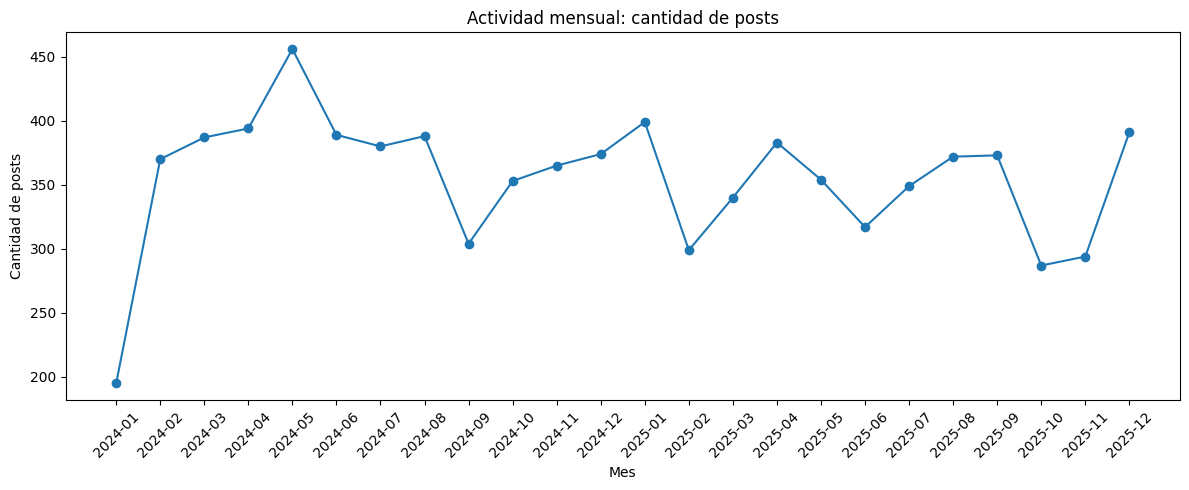

In [92]:


plt.figure(figsize=(12, 5))
plt.plot(monthly_trend["post_month"], monthly_trend["posts"], marker="o")
plt.xticks(rotation=45)
plt.title("Actividad mensual: cantidad de posts")
plt.xlabel("Mes")
plt.ylabel("Cantidad de posts")
plt.tight_layout()
plt.show()

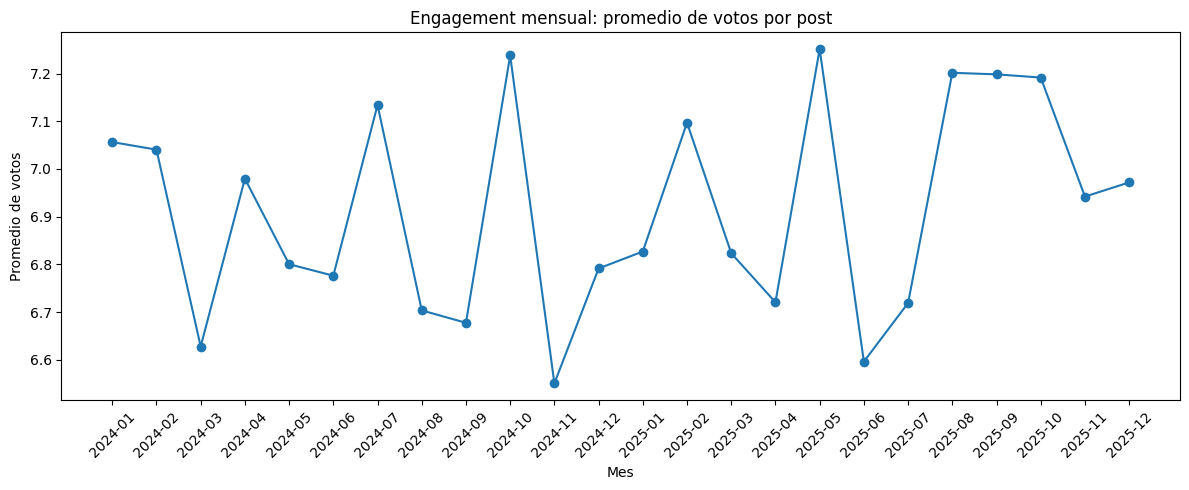

In [93]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_trend["post_month"], monthly_trend["avg_votes"], marker="o")
plt.xticks(rotation=45)
plt.title("Engagement mensual: promedio de votos por post")
plt.xlabel("Mes")
plt.ylabel("Promedio de votos")
plt.tight_layout()
plt.show()

In [94]:
# Segmentos por plan
segment_plan = data.groupby("plan_type").agg(
    users=("user_id", "nunique"),
    posts=("post_id", "count"),
    total_votes=("votes_received", "sum"),
    avg_votes=("votes_received", "mean"),
    median_votes=("votes_received", "median")
).sort_values("avg_votes", ascending=False)

segment_plan

,users,posts,total_votes,avg_votes,median_votes
plan_type,,,,,
pro,368,1608,12306,7.652985,7.0
enterprise,82,333,2521,7.570571,7.0
free,1547,6569,43961,6.692191,6.0
invalido,3,3,11,3.666667,3.0


In [95]:
# Segmentos por categoría
segment_category = data.groupby("post_category").agg(
    users=("user_id", "nunique"),
    posts=("post_id", "count"),
    total_votes=("votes_received", "sum"),
    avg_votes=("votes_received", "mean"),
    median_votes=("votes_received", "median")
).sort_values("avg_votes", ascending=False)

segment_category

,users,posts,total_votes,avg_votes,median_votes
post_category,,,,,
tech,901,1382,10625,7.688133,7.0
science,652,870,6564,7.544828,6.0
gaming,613,833,5986,7.186074,6.0
finance,646,854,5961,6.980094,6.0
travel,405,492,3384,6.878049,6.0
education,538,682,4625,6.781525,6.0
sports,722,1017,6685,6.573255,6.0
health,536,674,4346,6.448071,6.0
music,526,673,4231,6.286776,5.0


In [96]:
# Segmentos por dispositivo
segment_device = data.groupby("device_type").agg(
    users=("user_id", "nunique"),
    posts=("post_id", "count"),
    total_votes=("votes_received", "sum"),
    avg_votes=("votes_received", "mean"),
    median_votes=("votes_received", "median")
).sort_values("avg_votes", ascending=False)

segment_device

,users,posts,total_votes,avg_votes,median_votes
device_type,,,,,
desktop,340,583,4092,7.018868,6.0
web,1538,4270,29722,6.960656,6.0
mobile,1397,3657,24972,6.828548,6.0
invalido,3,3,13,4.333333,3.0


In [97]:
# ===============================
# Exportación de archivos finales
# ===============================

df_analysis.to_csv("clean_product_activity.csv", index=False)

df_quarantine.to_csv("quarantine_product_activity.csv", index=False)

metrics_summary = pd.concat([
    quality_report,
    concentration_report
], ignore_index=True)

metrics_summary.to_csv("metrics_summary.csv", index=False)

print("Archivos exportados correctamente:")
print("clean_product_activity.csv")
print("quarantine_product_activity.csv")
print("metrics_summary.csv")

Archivos exportados correctamente:
clean_product_activity.csv
quarantine_product_activity.csv
metrics_summary.csv


## Product Decisions y Conclusiones

A partir del análisis, se recomienda priorizar los segmentos con mejor equilibrio entre volumen de publicaciones y engagement. La decisión debe basarse en las tablas de segmentación por plan, categoría y dispositivo, considerando tanto la media como la mediana de votos para reducir el efecto de outliers.

Antes de la limpieza, el tablero podía mostrar información engañosa porque valores equivalentes aparecían separados por errores de escritura, mayúsculas o espacios. Por ejemplo, variantes de `pro`, `free`, `tech` o categorías mal escritas podían fragmentar los resultados.

Como nuevo dato de tracking, se recomienda agregar `post_views` o `impressions`, ya que actualmente solo se observan votos recibidos. Sin exposición, no es posible calcular una tasa real de engagement.

Acciones propuestas:
1. Priorizar el segmento con mejor combinación de volumen y votos promedio/medianos, usando las tablas de segmentación como respaldo.
2. Implementar validaciones de datos para evitar planes, dispositivos y categorías fuera de diccionario.

Limitaciones:
El dataset tiene como unidad de análisis el post, por lo que usuarios muy activos pesan más en los promedios por fila. Además, existen valores faltantes, registros en cuarentena y posibles outliers en votos.